## Load graph

In [1]:
import gzip
import pickle

with gzip.open(r"E:\SC4052 Cloud Computing\fast-graphrag\marie_curie_graph\graph_igraph_data.pklz", "rb") as f:
    graph = pickle.load(f)

# print(graph)
print("Num nodes:", graph.vcount())
print(graph.vs.attributes())

Num nodes: 1238
['type', 'description', 'name']


## Find seed nodes

In [24]:
def find_seed_nodes(graph, query_entities):
    seeds = []
    
    for v in graph.vs:
        name = v["name"].lower().strip()
        
        for q in query_entities:
            if name == q.lower(): # Exact matching first, had bug where we had like MARIE CURIE HIGH SCHOOL, MARIE CURIE CHARITY etc..
                seeds.append(v.index)
    
    return seeds

query_entities = ["Marie Curie", "medical imaging"]

seeds = find_seed_nodes(graph, query_entities)
print(seeds)
for idx in seeds:
    print(idx, graph.vs[idx]["name"])

[0, 48]
0 MARIE CURIE
48 MEDICAL IMAGING


## Run PPR


In [ ]:
import numpy as np

def personalized_pagerank(
    graph,
    seeds,
    damping=0.85,          # α
    max_iterations=100,
    tolerance=1e-6
):
    n = graph.vcount()

    # Step 1: Build adjacency matrix
    A = np.array(graph.get_adjacency().data, dtype=float)

    # Step 2: Column normalize (M matrix)
    col_sums = A.sum(axis=0)
    col_sums[col_sums == 0] = 1  # avoid division by zero (dangling nodes)
    M = A / col_sums

    # Step 3: Personalization vector p
    # [0, 48]
    # 0 MARIE CURIE
    # 48 MEDICAL IMAGING
    # With personalization: Random jump → Marie Curie / Medical Imaging
    # → importance spreads outward from them
    # → finds connecting concepts
    p = np.zeros(n)
    for s in seeds:
        p[s] = 1.0
    p = p / p.sum()

    # Step 4: Initialize ranks uniformly
    current_ranks = np.ones(n) / n

    l1_diffs = []  # track convergence

    for iteration in range(max_iterations):

        # Step 5: PageRank update
        next_ranks = damping * (M @ current_ranks) + (1 - damping) * p

        # Step 6: Compute L1 difference
        diff = np.linalg.norm(next_ranks - current_ranks, 1)
        l1_diffs.append(diff)

        if diff < tolerance:
            print(f"Converged in {iteration} iterations")
            break

        current_ranks = next_ranks

    return current_ranks, l1_diffs


## Get top-k nodes

In [38]:
def get_top_k(graph, scores, k=10):
    ranked = sorted(
        [(i, score) for i, score in enumerate(scores)],
        key=lambda x: x[1],
        reverse=True
    )
    
    results = []
    for i, score in ranked[:k]:
        results.append((graph.vs[i]["name"], score))
    
    return results

## Full pipeline

In [41]:
scores, l1_diffs = personalized_pagerank(graph, seeds)

top_k = get_top_k(graph, scores, k=10)

for name, score in top_k:
    print(name, score)

Converged in 70 iterations
MARIE CURIE 0.1839620637333739
MEDICAL IMAGING 0.17425605062070132
RADIUM 0.02224106538501915
X-RAY 0.019433582751240866
RADIOACTIVITY 0.012372182849832844
POLONIUM 0.011187205174136598
PIERRE CURIE 0.0110486838791668
NUCLEAR MEDICINE 0.007015032753794636
MRI 0.0062975734825070654
X-RAYS 0.006167062570821577


Converged in 70 iterations


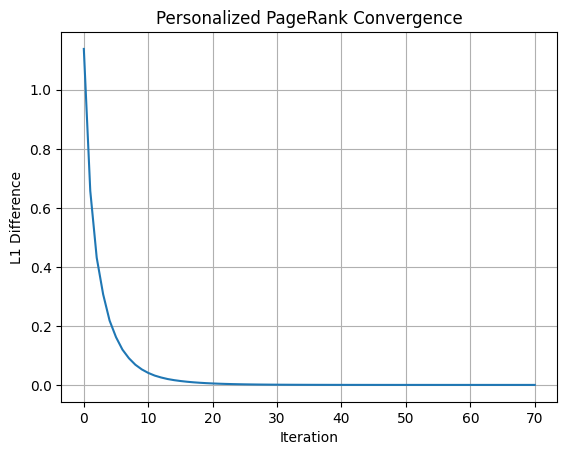

In [42]:
##Plot
import matplotlib.pyplot as plt

ranks, l1_diffs = personalized_pagerank(graph, seeds)

plt.plot(l1_diffs)
plt.xlabel("Iteration")
plt.ylabel("L1 Difference")
plt.title("Personalized PageRank Convergence")
plt.grid()
plt.show()